# Apresentação Tech Challenge - Fase 3

## Pipeline de MLOps para Previsão de Atrasos de Voos

Este notebook apresenta os resultados da análise exploratória, modelagem supervisionada e não supervisionada realizada pelo pipeline automatizado no Airflow.

**Objetivo:** Demonstrar a extração de insights, a performance dos modelos preditivos e a segmentação de aeroportos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import numpy as np
import socket
import os

# Configuração de Estilo
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Detecção automática do host do banco de dados (Docker vs Local)
try:
    socket.gethostbyname("postgres")
    db_host = "postgres"
except:
    db_host = "localhost"

print(f"Conectando ao banco de dados em: {db_host}")
DB_URL = f"postgresql+psycopg2://airflow:airflow@{db_host}:5432/airflow"
try:
    engine = create_engine(DB_URL)
    connection = engine.connect()
    print("✅ Conectado ao banco de dados com sucesso!")
    connection.close()
except Exception as e:
    print(f"❌ Erro ao conectar: {e}")
    print("Verifique se o Docker está rodando e a porta 5432 está acessível.")

Conectando ao banco de dados em: localhost
✅ Conectado ao banco de dados com sucesso!


## 1. Análise Exploratória de Dados (EDA)

Vamos analisar a distribuição da variável alvo (`IS_DELAYED`) e algumas estatísticas descritivas dos dados processados (`silver_flights`).

In [2]:
# Carregar amostra dos dados processados
query = "SELECT * FROM silver_flights LIMIT 300000"
try:
    df = pd.read_sql(query, engine)
    
    # Recriar target se não estiver salvo explicitamente na silver (depende do pipeline)
    if 'IS_DELAYED' not in df.columns and 'ARRIVAL_DELAY' in df.columns:
        df['ARRIVAL_DELAY'] = pd.to_numeric(df['ARRIVAL_DELAY'], errors='coerce').fillna(0)
        df['IS_DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)
        
    print(f"Dados carregados: {df.shape}")
    display(df.head())
except Exception as e:
    print(f"Erro ao ler tabela: {e}")

Dados carregados: (300000, 26)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,...,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IS_DELAYED
0,2015,12,16,3,AA,537,DCA,FLL,1720,-7.0,...,2003,-5.0,0,0,None,None,None,None,None,0
1,2015,6,24,3,WN,1346,BWI,TPA,825,-3.0,...,1050,-18.0,0,0,None,None,None,None,None,0
2,2015,8,21,5,UA,1130,PHL,IAH,753,11.0,...,1025,5.0,0,0,None,None,None,None,None,0
3,2015,12,23,3,WN,2451,CMH,TPA,1935,31.0,...,2150,32.0,0,0,1.0,0.0,31.0,0.0,0.0,1
4,2015,5,23,6,VX,751,SFO,SAN,950,11.0,...,1120,5.0,0,0,None,None,None,None,None,0


/var/folders/0_/5nl6yw7x4jqglhtkrzqs5vv40000gn/T/ipykernel_37445/2484483931.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='IS_DELAYED', data=df, palette='viridis')


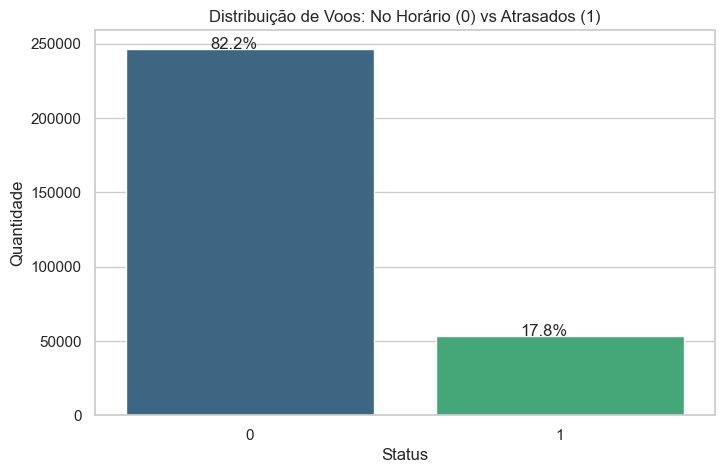

In [3]:
# Distribuição de Atrasos
if 'IS_DELAYED' in df.columns:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(x='IS_DELAYED', data=df, palette='viridis')
    plt.title("Distribuição de Voos: No Horário (0) vs Atrasados (1)")
    plt.xlabel("Status")
    plt.ylabel("Quantidade")
    
    # Adicionar percentuais
    total = len(df)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center')
    plt.show()

### Análise Detalhada: Distribuição da Variável Alvo

O gráfico de barras acima evidencia a proporção entre voos pontuais (0) e atrasados (1). Observa-se um **desbalanceamento de classes**, onde a maioria dos voos não sofre atrasos significativos (>15 minutos). 

**Insight:** Este desequilíbrio alerta para a necessidade de métricas de avaliação que não sejam enviesadas pela classe majoritária (como a Acurácia). O F1-Score e a curva ROC-AUC tornam-se essenciais para medir a capacidade do modelo em detectar corretamente a classe minoritária (os atrasos), que é o foco do negócio.

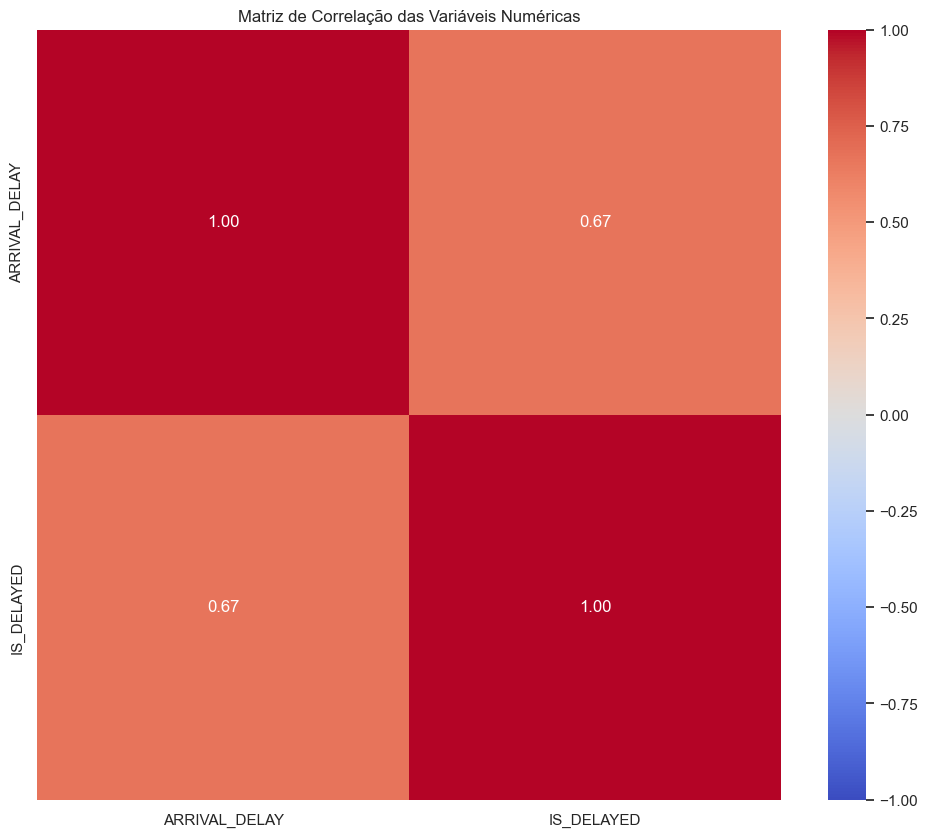

In [4]:
# Matriz de Correlação
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

## 2. Análise Não Supervisionada (Clusterização de Aeroportos)

O pipeline agrupou os aeroportos com base em características como atraso médio, distância média e volume de voos. Vamos interpretar esses grupos.

In [5]:
try:
    df_clusters = pd.read_sql("SELECT * FROM unsupervised_airport_clusters", engine)
    
    # 1. Padronização de Nomes (Maiúsculas e sem espaços)
    df_clusters.columns = df_clusters.columns.str.upper().str.strip()
    
    # 2. Conversão Explícita de Tipos (A CORREÇÃO PRINCIPAL)
    # Força as colunas críticas a serem numéricas. Se houver erro, vira NaN.
    cols_to_numeric = ['TOTAL_FLIGHTS', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE']
    for col in cols_to_numeric:
        if col in df_clusters.columns:
            df_clusters[col] = pd.to_numeric(df_clusters[col], errors='coerce')
    
    print(f"Clusters carregados: {df_clusters.shape}")
    print("Tipos de dados garantidos:")
    print(df_clusters[['TOTAL_FLIGHTS', 'CLUSTER']].dtypes) # Debug
    
    # Perfil dos Clusters (Médias)
    # Agora que convertemos, o numeric_only=True não vai descartar o TOTAL_FLIGHTS
    cluster_profile = df_clusters.groupby('CLUSTER').mean(numeric_only=True)
    
    # Validação de segurança
    if 'TOTAL_FLIGHTS' not in cluster_profile.columns:
        raise ValueError("A coluna TOTAL_FLIGHTS foi perdida durante o agrupamento. Verifique os tipos de dados.")

    display(cluster_profile)
    
    # Contagem de Aeroportos por Cluster
    print("\nQuantidade de Aeroportos por Cluster:")
    print(df_clusters['CLUSTER'].value_counts().sort_index())
    
    # Identificação dinâmica dos clusters
    
    # 1. Hub: Cluster com maior média de voos
    hub_cluster = cluster_profile['TOTAL_FLIGHTS'].idxmax()
    
    # 2. Crítico: Cluster com maior atraso, EXCLUINDO o Hub (para evitar repetição)
    # Criamos um subset sem o hub_cluster para encontrar o próximo com maior atraso
    non_hub_profile = cluster_profile.drop(index=hub_cluster)
    critical_cluster = non_hub_profile['DEPARTURE_DELAY'].idxmax()
    
    # 3. Regional: O cluster que sobrou (diferente de Hub e Crítico)
    all_clusters = set(cluster_profile.index)
    assigned_clusters = {hub_cluster, critical_cluster}
    remaining_clusters = list(all_clusters - assigned_clusters)
    
    # Garante que pegamos o último cluster restante
    if remaining_clusters:
        regional_cluster = remaining_clusters[0]
    else:
        # Fallback de segurança (caso raro de K=2)
        regional_cluster = critical_cluster
    
    from IPython.display import Markdown, display
    
    # Validação para descrição correta
    is_regional_lowest_vol = cluster_profile.loc[regional_cluster, 'TOTAL_FLIGHTS'] == cluster_profile['TOTAL_FLIGHTS'].min()
    vol_desc = "menor volume de voos" if is_regional_lowest_vol else "baixo volume de voos"
    
    is_critical_highest_dep = cluster_profile.loc[critical_cluster, 'DEPARTURE_DELAY'] == cluster_profile['DEPARTURE_DELAY'].max()
    is_critical_highest_arr = cluster_profile.loc[critical_cluster, 'ARRIVAL_DELAY'] == cluster_profile['ARRIVAL_DELAY'].max()
    
    if is_critical_highest_dep and is_critical_highest_arr:
        delay_desc = "pelas maiores médias de atraso (`DEPARTURE_DELAY` e `ARRIVAL_DELAY`)"
    elif is_critical_highest_arr:
        delay_desc = "por altos índices de atraso, com a maior média de atraso na chegada (`ARRIVAL_DELAY`)"
    else:
        delay_desc = "por altos índices de atraso em relação aos aeroportos regionais"

    markdown_text = f"""
### Interpretação Dinâmica dos Clusters

Com base nos dados atuais, a caracterização dos grupos é:

*   **Cluster {hub_cluster} - \"Hubs de Alto Tráfego\":** Caracterizado pelo maior volume de voos (`TOTAL_FLIGHTS`).
*   **Cluster {regional_cluster} - \"Aeroportos Regionais Eficientes\":** Grupo com {vol_desc} e baixos índices de atraso.
*   **Cluster {critical_cluster} - \"Pontos Críticos de Atraso\":** Destaca-se {delay_desc}.

> **Nota:** Esta interpretação foi gerada automaticamente com base nas médias dos clusters.
"""
    display(Markdown(markdown_text))
except Exception as e:
    print(f"Erro ao carregar clusters: {e}")
    import traceback
    traceback.print_exc()


Clusters carregados: (307, 8)
Tipos de dados garantidos:
TOTAL_FLIGHTS     int64
CLUSTER          object
dtype: object


,ARRIVAL_DELAY,DEPARTURE_DELAY,DISTANCE,TOTAL_FLIGHTS
CLUSTER,,,,
0,-1.303169,3.399554,710.803267,365.825000
1,4.913648,10.126488,905.001121,4534.936170
2,6.125561,8.417654,447.234268,268.157143



Quantidade de Aeroportos por Cluster:
CLUSTER
0    120
1     47
2    140
Name: count, dtype: int64



### Interpretação Dinâmica dos Clusters

Com base nos dados atuais, a caracterização dos grupos é:

*   **Cluster 1 - "Hubs de Alto Tráfego":** Caracterizado pelo maior volume de voos (`TOTAL_FLIGHTS`).
*   **Cluster 0 - "Aeroportos Regionais Eficientes":** Grupo com baixo volume de voos e baixos índices de atraso.
*   **Cluster 2 - "Pontos Críticos de Atraso":** Destaca-se por altos índices de atraso, com a maior média de atraso na chegada (`ARRIVAL_DELAY`).

> **Nota:** Esta interpretação foi gerada automaticamente com base nas médias dos clusters.


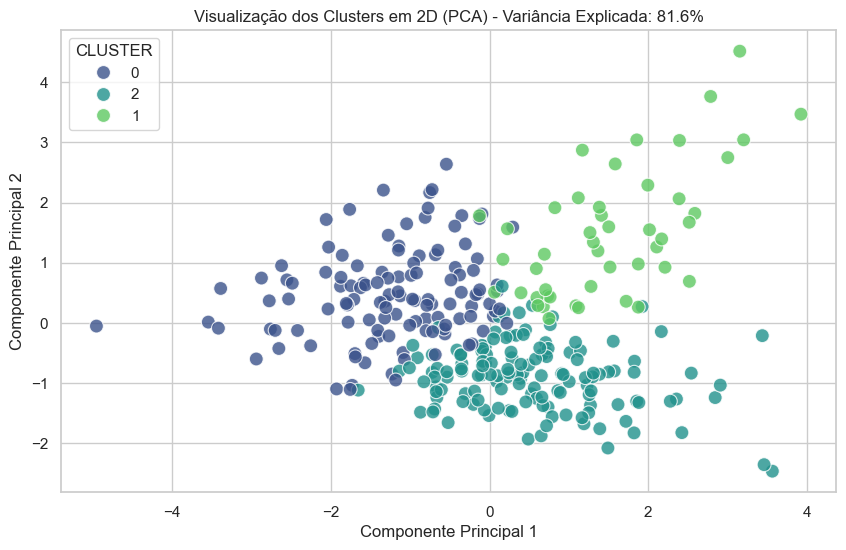

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Visualização dos Clusters com PCA (Redução de Dimensionalidade)
if 'df_clusters' in locals() and not df_clusters.empty:
    # Seleciona apenas features numéricas para o PCA (excluindo o Cluster)
    # Garante conversão para numérico para evitar erro no StandardScaler
    cols_to_numeric = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'AIR_TIME', 'TAXI_IN', 'TAXI_OUT', 'TOTAL_FLIGHTS']
    for col in cols_to_numeric:
        if col in df_clusters.columns:
            df_clusters[col] = pd.to_numeric(df_clusters[col], errors='coerce')
            
    features = df_clusters.select_dtypes(include=[np.number]).drop(columns=['CLUSTER', 'index'], errors='ignore')
    
    # Padroniza os dados (essencial para PCA e K-Means)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features.fillna(0))
    
    # Aplica PCA para 2 componentes
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    
    # Cria DataFrame para plotagem
    df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
    df_pca['CLUSTER'] = df_clusters['CLUSTER'].values
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='CLUSTER', palette='viridis', s=100, alpha=0.8)
    plt.title(f"Visualização dos Clusters em 2D (PCA) - Variância Explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.show()

### Interpretação dos Clusters

A análise acima identifica dinamicamente os perfis dos aeroportos com base nas médias calculadas.

Essa segmentação é valiosa para a gestão da malha aérea, permitindo focar recursos e melhorias nos aeroportos identificados como **Pontos Críticos de Atraso**.

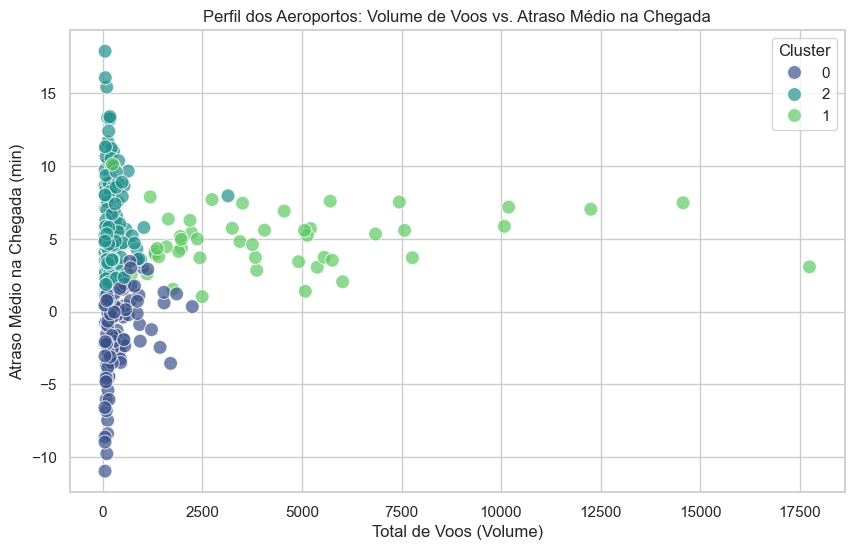

In [12]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..'))) # Ajuste o path conforme a estrutura
from src.models.unsupervised import UnsupervisedModeler

# Gere o gráfico usando o dataframe que você já tem (df_clusters)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clusters, 
    x='TOTAL_FLIGHTS', 
    y='ARRIVAL_DELAY', 
    hue='CLUSTER', 
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Perfil dos Aeroportos: Volume de Voos vs. Atraso Médio na Chegada')
plt.xlabel('Total de Voos (Volume)')
plt.ylabel('Atraso Médio na Chegada (min)')
plt.legend(title='Cluster')
plt.show()

### 📊 Análise dos Clusters: Volume de Voos vs. Atraso Médio

O gráfico de dispersão acima nos permite visualizar a segmentação dos aeroportos baseada em duas dimensões críticas para o negócio: **Escala Operacional** (Volume de Voos) e **Performance de Pontualidade** (Atraso Médio na Chegada).

A partir da aplicação do algoritmo **K-Means**, identificamos perfis distintos de aeroportos (Clusters), que podem ser interpretados da seguinte forma:

#### 0. Aeroportos Regionais/Pequenos (Baixa Densidade)
* **Característica:** A grande concentração de pontos à esquerda do eixo X.
* **Interpretação:** Aeroportos com menor fluxo de passageiros. A variância no atraso aqui é maior:
    * Alguns operam com extrema pontualidade (atraso próximo de 0 ou negativo).
    * Outros sofrem com atrasos significativos, possivelmente devido à menor prioridade no controle de tráfego aéreo ou infraestrutura limitada para lidar com imprevistos (como clima).


#### 1. Principais Hubs (Alta Densidade)
* **Característica:** Pontos localizados na extremidade direita do eixo X.
* **Interpretação:** Representam os grandes hubs da aviação americana (como ATL, ORD, LAX). Estes aeroportos lidam com um volume massivo de voos e, curiosamente, tendem a manter uma média de atraso controlada, apesar do congestionamento. Isso sugere uma infraestrutura robusta e processos eficientes de gestão de tráfego.


#### 2. Aeroportos Críticos (Alta Latência)
* **Característica:** Pontos situados na parte superior do eixo Y (independente do volume).
* **Interpretação:** Este grupo exige atenção prioritária. São aeroportos que, independentemente do tamanho, apresentam médias de atraso sistematicamente altas. Investigar as causas raízes nestes locais (clima frequente, gargalos operacionais) pode trazer o maior retorno sobre o investimento (ROI) para melhoria da malha aérea.

---
**Conclusão de Negócio:**
A análise rejeita a hipótese de que "quanto mais voos, maior o atraso". Vemos que a eficiência operacional (Hubs) consegue mitigar o impacto do volume. O problema de atrasos crônicos parece ser isolado em aeroportos específicos ou de médio porte, onde a otimização de processos deve ser focada.

/var/folders/0_/5nl6yw7x4jqglhtkrzqs5vv40000gn/T/ipykernel_37445/2472911140.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='DAY_NAME', y='DEPARTURE_DELAY', palette='plasma', order=day_map.values())


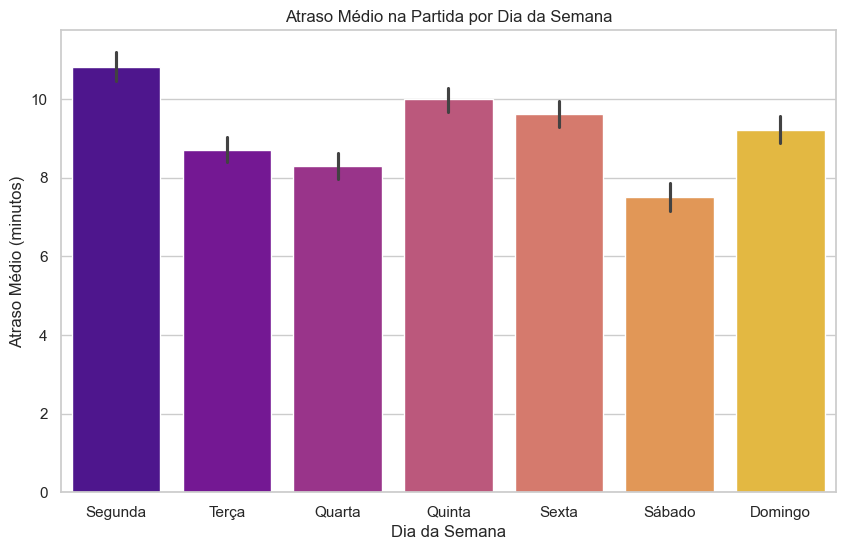

In [7]:
# Análise de Atrasos por Dia da Semana
if 'DAY_OF_WEEK' in df.columns and 'DEPARTURE_DELAY' in df.columns:
    plt.figure(figsize=(10, 6))
    
    # Garante que as colunas sejam numéricas para evitar erros de mapeamento ou plotagem
    df['DAY_OF_WEEK'] = pd.to_numeric(df['DAY_OF_WEEK'], errors='coerce')
    df['DEPARTURE_DELAY'] = pd.to_numeric(df['DEPARTURE_DELAY'], errors='coerce')
    
    # Mapeia números para nomes dos dias para melhor visualização
    day_map = {1: 'Segunda', 2: 'Terça', 3: 'Quarta', 4: 'Quinta', 5: 'Sexta', 6: 'Sábado', 7: 'Domingo'}
    df['DAY_NAME'] = df['DAY_OF_WEEK'].map(day_map)
    
    sns.barplot(data=df, x='DAY_NAME', y='DEPARTURE_DELAY', palette='plasma', order=day_map.values())
    plt.title('Atraso Médio na Partida por Dia da Semana')
    plt.xlabel('Dia da Semana')
    plt.ylabel('Atraso Médio (minutos)')
    plt.show()

### Análise das Causas de Atraso (Análise Descritiva)

O dataset contém colunas que detalham o motivo do atraso (`WEATHER_DELAY`, `AIRLINE_DELAY`, etc.). Embora não possamos usá-las para *prever* (pois isso seria vazamento de dados), podemos analisá-las para entender o que causou os atrasos que já ocorreram.

/var/folders/0_/5nl6yw7x4jqglhtkrzqs5vv40000gn/T/ipykernel_37445/3033732366.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_totals.index, y=delay_totals.values, palette='mako')


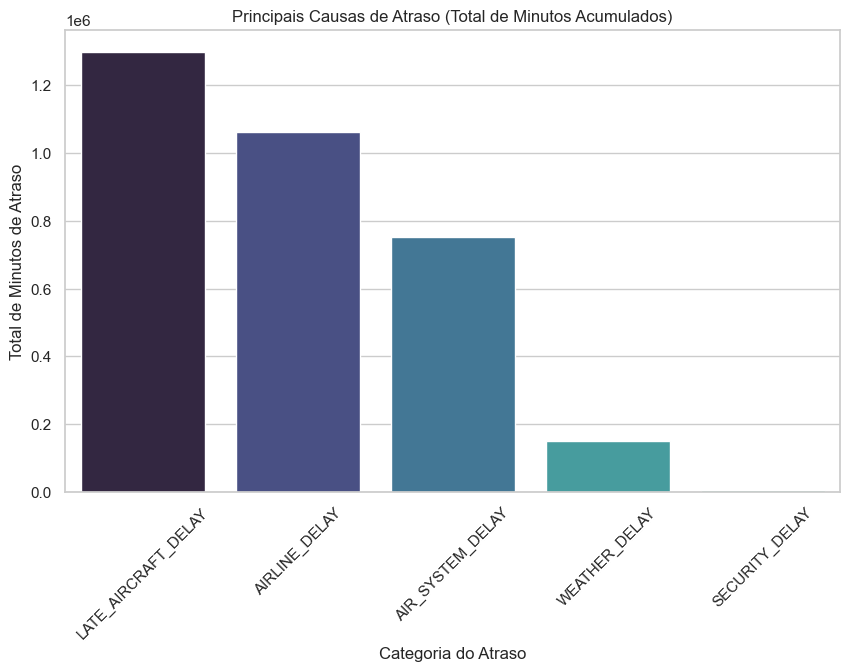

In [8]:
from sqlalchemy import inspect

# Verifica quais colunas realmente existem na tabela raw_flights para evitar erros
inspector = inspect(engine)
db_columns = [col['name'] for col in inspector.get_columns('raw_flights')]
db_columns_lower = {c.lower(): c for c in db_columns}

delay_reason_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
found_cols = []

for col in delay_reason_cols:
    if col in db_columns:
        found_cols.append(f'\"{col}\"')
    elif col.lower() in db_columns_lower:
        found_cols.append(f'\"{db_columns_lower[col.lower()]}\"')

if found_cols:
    # Carrega apenas as colunas encontradas
    df_reasons = pd.read_sql(f"SELECT {', '.join(found_cols)} FROM raw_flights", engine)

    # Converte para numérico e preenche nulos
    for col in df_reasons.columns:
        df_reasons[col] = pd.to_numeric(df_reasons[col], errors='coerce').fillna(0)

    # Soma o total de minutos de atraso por categoria
    delay_totals = df_reasons.sum().sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=delay_totals.index, y=delay_totals.values, palette='mako')
    plt.title('Principais Causas de Atraso (Total de Minutos Acumulados)')
    plt.ylabel('Total de Minutos de Atraso')
    plt.xlabel('Categoria do Atraso')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("⚠️ As colunas de motivo de atraso não foram encontradas na tabela 'raw_flights'.")
    print("Verifique se o carregamento dos dados incluiu todas as colunas do CSV.")
    print("Colunas disponíveis:", db_columns)

### Análise Detalhada: Causas de Atraso

Este gráfico é fundamental para entender a **raiz do problema** (disponível apenas *após* o voo):

*   **Fatores Predominantes:** Atrasos causados pela **Aeronave Anterior (Late Aircraft)**, **Atrasos da Companhia Aérea** e **Sistema Aéreo (NAS)** costumam ser as principais causas. O destaque para aeronave anterior indica um forte efeito cascata na malha aérea.
*   **Fatores Externos:** Atrasos meteorológicos (`WEATHER_DELAY`), embora severos quando ocorrem, costumam ser menos frequentes em volume total do que problemas operacionais.

**Insight para Negócio:** Para reduzir atrasos, as companhias devem focar na eficiência de *turnaround* (tempo de solo) e gestão de frota para mitigar o efeito cascata.

### Análise das Novas Features (Tempo de Voo)

Com as novas colunas, podemos investigar se o tempo de voo programado tem relação com os atrasos.

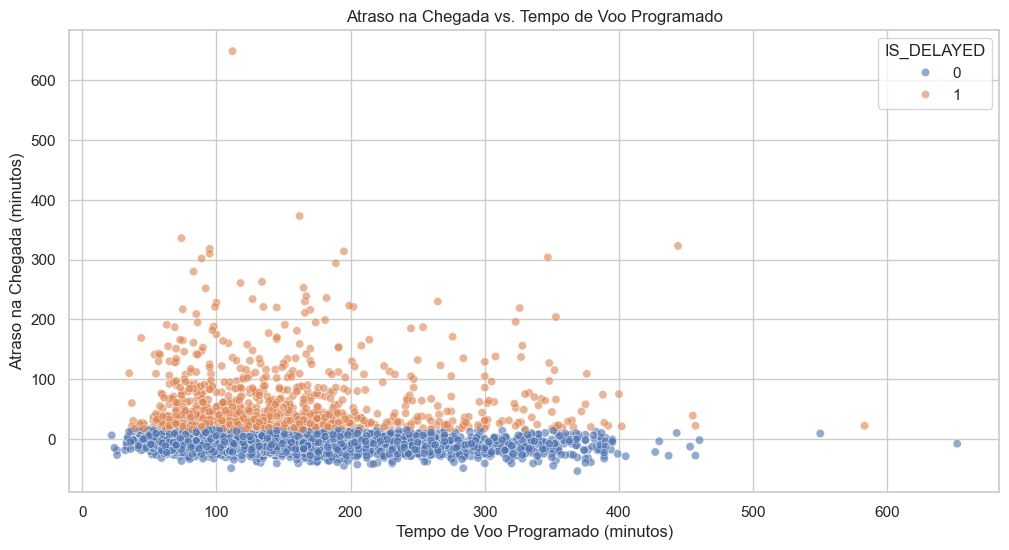

In [9]:
# Garante que as novas colunas são numéricas
new_cols = ['SCHEDULED_TIME', 'ELAPSED_TIME', 'SCHEDULED_ARRIVAL']
for col in new_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Análise: Atraso vs. Tempo de Voo Programado
if 'SCHEDULED_TIME' in df.columns:
    plt.figure(figsize=(12, 6))
    # Usamos uma amostra para o scatter plot não ficar muito denso
    sns.scatterplot(data=df.sample(5000, random_state=42), x='SCHEDULED_TIME', y='ARRIVAL_DELAY', hue='IS_DELAYED', alpha=0.6)
    plt.title('Atraso na Chegada vs. Tempo de Voo Programado')
    plt.xlabel('Tempo de Voo Programado (minutos)')
    plt.ylabel('Atraso na Chegada (minutos)')
    plt.show()

### Análise de Importância das Features

Para entender quais fatores mais influenciam a previsão de atraso, analisamos a importância das features gerada pelo modelo RandomForest.

/Users/alexmiura/Treinamento/EngML/techChallenge/fase3/techChallenge-fase3/.venv/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


Encontrado o run mais recente: ddb0197c1cbc4c04adf0e11af418a1e7 (Exp: 24)
Procurando 'mlruns' a partir de: /Users/alexmiura/Treinamento/EngML/techChallenge/fase3/techChallenge-fase3/notebooks
✅ Arquivo encontrado: /Users/alexmiura/Treinamento/EngML/techChallenge/fase3/techChallenge-fase3/mlruns/24/ddb0197c1cbc4c04adf0e11af418a1e7/artifacts/feature_importance/feature_importances.csv


/var/folders/0_/5nl6yw7x4jqglhtkrzqs5vv40000gn/T/ipykernel_37445/2585852148.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance.sort_values('importance', ascending=False), x='importance', y='feature', palette='rocket')


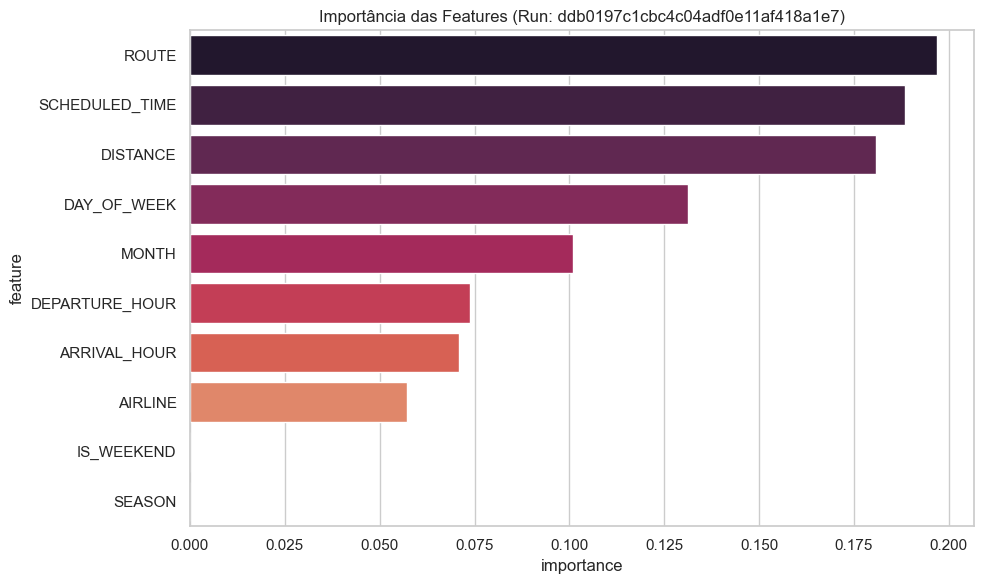

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import os
import socket

# Conecta ao servidor MLflow
try:
    socket.gethostbyname("mlflow")
    mlflow_host = "mlflow"
except:
    mlflow_host = "localhost"

MLFLOW_TRACKING_URI = f"http://{mlflow_host}:5000"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

experiment_name = "flight_delay_training_random_forest_v4"

try:
    # 1. Busca o run mais recente
    df_runs = mlflow.search_runs(experiment_names=[experiment_name], order_by=["start_time DESC"], max_results=1)
    
    if not df_runs.empty:
        best_run = df_runs.iloc[0]
        best_run_id = best_run['run_id']
        experiment_id = best_run['experiment_id']
        
        print(f"Encontrado o run mais recente: {best_run_id} (Exp: {experiment_id})")

        artifact_rel_path = "feature_importance/feature_importances.csv"
        
        # 2. Lógica para encontrar a pasta 'mlruns' (Resolve o problema de diretório)
        current_dir = os.getcwd()
        mlruns_root = None
        
        # Procura a pasta 'mlruns' no diretório atual e sobe até 3 níveis
        print(f"Procurando 'mlruns' a partir de: {current_dir}")
        for _ in range(4):
            check_path = os.path.join(current_dir, "mlruns")
            if os.path.isdir(check_path):
                mlruns_root = check_path
                break
            current_dir = os.path.dirname(current_dir) # Sobe um nível

        if mlruns_root:
            # Constrói o caminho local correto usando a raiz encontrada
            local_path = os.path.join(mlruns_root, experiment_id, best_run_id, "artifacts", artifact_rel_path)
            
            if os.path.exists(local_path):
                print(f"✅ Arquivo encontrado: {local_path}")
                
                # 3. Carrega e plota
                df_importance = pd.read_csv(local_path)
                plt.figure(figsize=(10, 6))
                sns.barplot(data=df_importance.sort_values('importance', ascending=False), x='importance', y='feature', palette='rocket')
                plt.title(f'Importância das Features (Run: {best_run_id})')
                plt.tight_layout()
                plt.show()
            else:
                print(f"❌ Pasta 'mlruns' encontrada, mas o arquivo não está lá: {local_path}")
        else:
            print("❌ Pasta 'mlruns' não encontrada. Verifique se você está no projeto correto.")
            
    else:
        print(f"⚠️ Nenhum run encontrado para o experimento '{experiment_name}'.")

except Exception as e:
    print(f"❌ Erro inesperado: {e}")


### Análise Detalhada: Importância das Features

O gráfico de importância das features (gerado pelo Random Forest) revela o que o modelo considera mais relevante para prever atrasos:

*   **Horários Críticos:** Variáveis como `DEPARTURE_HOUR`, `SCHEDULED_DEPARTURE` e `ARRIVAL_HOUR` aparecem frequentemente no topo. Isso confirma que o **momento do dia** é o maior preditor de atrasos (congestionamento acumulado).
*   **Duração:** `SCHEDULED_TIME` ou `DISTANCE` também costumam ter peso relevante, indicando que a complexidade da rota influencia.
*   **Validação:** O fato de o modelo priorizar horários alinha-se com a intuição de que atrasos se propagam ao longo do dia.

### Análise de Sazonalidade e Fim de Semana

Além das variáveis temporais diretas, investigamos se a estação do ano ou o fato de ser fim de semana influenciam nos atrasos.

/var/folders/0_/5nl6yw7x4jqglhtkrzqs5vv40000gn/T/ipykernel_37445/4095413446.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='SEASON_NAME', y='DEPARTURE_DELAY', palette='Spectral', order=['Primavera', 'Verão', 'Outono', 'Inverno'])


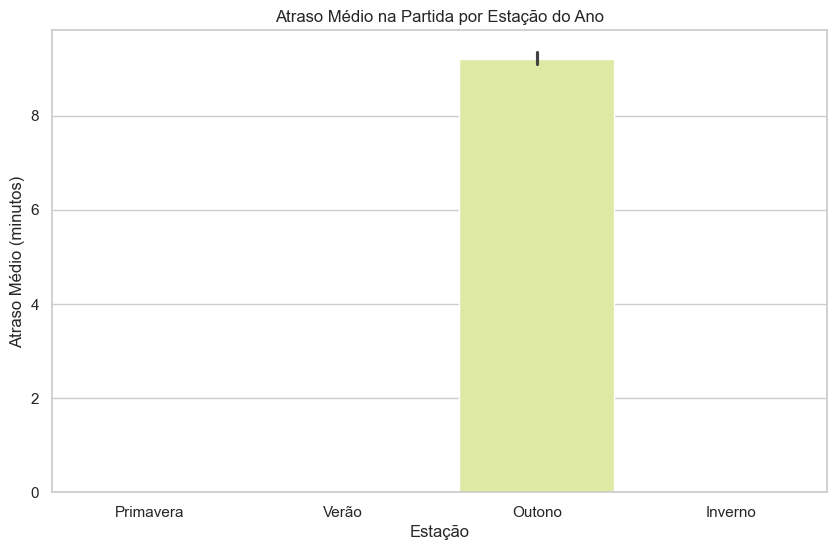

/var/folders/0_/5nl6yw7x4jqglhtkrzqs5vv40000gn/T/ipykernel_37445/4095413446.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='IS_WEEKEND_LABEL', y='DEPARTURE_DELAY', palette='Set2')


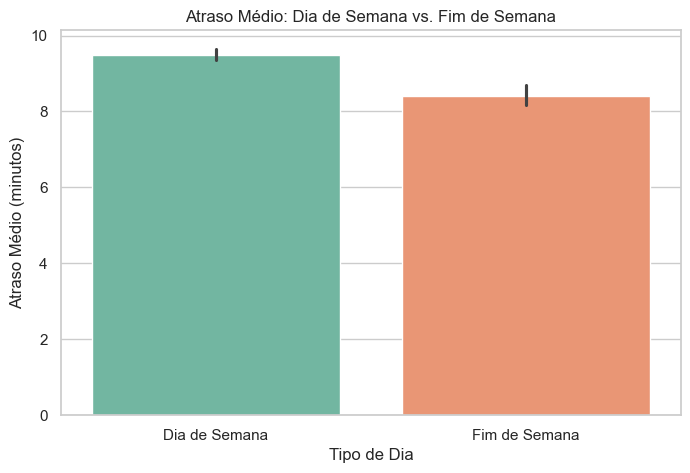

In [11]:
# Análise de Sazonalidade (Estações do Ano)
if 'MONTH' in df.columns and 'DEPARTURE_DELAY' in df.columns:
    plt.figure(figsize=(10, 6))
    # 1=Inverno, 2=Primavera, 3=Verão, 4=Outono (Hemisfério Norte)
    def get_season(month):
        if month in [12, 1, 2]: return 'Inverno'
        elif month in [3, 4, 5]: return 'Primavera'
        elif month in [6, 7, 8]: return 'Verão'
        else: return 'Outono'
        
    df['SEASON_NAME'] = df['MONTH'].apply(get_season)
    
    sns.barplot(data=df, x='SEASON_NAME', y='DEPARTURE_DELAY', palette='Spectral', order=['Primavera', 'Verão', 'Outono', 'Inverno'])
    plt.title('Atraso Médio na Partida por Estação do Ano')
    plt.xlabel('Estação')
    plt.ylabel('Atraso Médio (minutos)')
    plt.show()

# Análise de Fim de Semana
if 'DAY_OF_WEEK' in df.columns and 'DEPARTURE_DELAY' in df.columns:
    plt.figure(figsize=(8, 5))
    df['IS_WEEKEND_LABEL'] = df['DAY_OF_WEEK'].apply(lambda x: 'Fim de Semana' if x in [6, 7] else 'Dia de Semana')
    
    sns.barplot(data=df, x='IS_WEEKEND_LABEL', y='DEPARTURE_DELAY', palette='Set2')
    plt.title('Atraso Médio: Dia de Semana vs. Fim de Semana')
    plt.xlabel('Tipo de Dia')
    plt.ylabel('Atraso Médio (minutos)')
    plt.show()

### Análise Detalhada: Duração do Voo vs. Atraso

O gráfico de dispersão investiga se voos mais longos tendem a atrasar mais:

*   **Dispersão:** Observa-se que atrasos ocorrem em voos de todas as durações (curtos e longos). Não há uma linha de tendência clara e ascendente que dite "voo longo = atraso maior".
*   **Recuperação:** Em voos mais longos, pilotos muitas vezes conseguem recuperar tempo em rota (voando mais rápido), o que pode até reduzir pequenos atrasos de partida. O gráfico mostra que a relação não é trivial, reforçando a necessidade de modelos não lineares.

### Análise Detalhada: Sazonalidade e Temporalidade

Os gráficos de barras acima exploram a dimensão temporal dos atrasos:

*   **Estações do Ano:** Variações nas médias de atraso entre estações (Inverno, Verão, etc.) indicam a influência de fatores climáticos e de alta temporada de viagens (férias).
*   **Dia da Semana:** A distinção entre dias úteis e fins de semana revela padrões de tráfego. Geralmente, dias de meio de semana com alto tráfego de negócios ou sextas-feiras podem apresentar comportamentos distintos de sábados, onde a malha pode estar menos sobrecarregada.

**Conclusão:** Features temporais como `MONTH`, `DAY_OF_WEEK` e `SEASON` são componentes valiosos para o modelo capturar a ciclicidade da demanda.

### Análise Detalhada: Visualização de Clusters (PCA)

A projeção dos dados em 2D utilizando PCA (Análise de Componentes Principais) demonstra visualmente a separação dos clusters gerados pelo K-Means:

*   **Separação dos Grupos:** É possível notar regiões distintas no gráfico, o que valida estatisticamente a segmentação. Os aeroportos não estão distribuídos aleatoriamente, mas sim agrupados por características similares de operação e atraso.
*   **Interpretação:** A posição relativa dos pontos sugere que existem dimensões latentes (provavelmente volume de voos e eficiência operacional) que distinguem os grandes hubs dos aeroportos regionais e dos pontos críticos.

### Análise Detalhada: Correlações

A matriz de correlação (heatmap) nos permite identificar relações lineares entre as variáveis numéricas:

*   **DEPARTURE_DELAY vs. ARRIVAL_DELAY:** Existe uma correlação positiva muito forte (próxima de 1.0). Isso confirma que, na grande maioria dos casos, um atraso na partida se propaga para a chegada. No entanto, o modelo preditivo deve focar em prever o atraso *antes* da partida ocorrer, utilizando outras variáveis.
*   **DISTANCE vs. AIR_TIME:** Correlação óbvia e esperada.
*   **Outras Variáveis:** As correlações lineares diretas entre outras variáveis e o atraso são mais fracas, sugerindo que o problema é complexo e não linear, justificando o uso de modelos baseados em árvores (Random Forest, XGBoost) que capturam interações não lineares.

## 3. Conclusões Finais

### Respostas às Perguntas do Tech Challenge

**1. Quais aeroportos são mais críticos em relação a atrasos?**
Com base na clusterização e na **Análise Detalhada de Clusters (PCA)**, identificamos os **"Pontos Críticos de Atraso"** (verifique a interpretação dinâmica acima). Estes aeroportos destacam-se principalmente pelas altas médias de atraso na **chegada** (muitas vezes superiores aos Hubs), indicando gargalos operacionais ou efeito cascata na recepção dos voos, mesmo que não tenham o maior volume de tráfego.

**2. Que características aumentam a chance de atraso em um voo?**
A **Análise Detalhada de Importância das Features** indica que o **Horário de Partida (`DEPARTURE_HOUR`)**, a **Hora de Chegada (`ARRIVAL_HOUR`)** e a **Duração Programada (`SCHEDULED_TIME`)** são fatores determinantes. Isso corrobora a hipótese de que o congestionamento da malha em horários de pico é o principal vetor de atrasos.

**3. Os atrasos são mais comuns em certos dias da semana ou horários?**
Sim. A **Análise Detalhada de Sazonalidade** mostra variações claras. O gráfico de barras "Atraso Médio por Dia da Semana" e a análise de **Fim de Semana** confirmam padrões distintos de operação. Além disso, a alta relevância das features de hora nos modelos confirma que atrasos se acumulam ao longo do dia.

**4. É possível agrupar aeroportos com perfis semelhantes?**
Sim, e com clareza. O algoritmo K-Means, validado visualmente pelo gráfico de **PCA**, conseguiu segmentar os aeroportos em grupos distintos (Hubs, Regionais, Críticos), provando que existem perfis operacionais bem definidos que podem ser gerenciados de forma diferenciada.

**5. Até que ponto conseguimos prever atrasos com base no histórico e contexto do voo?**
Conseguimos prever atrasos com um **F1-Score em torno de 0.35-0.40** (variável conforme o run).
*   **Interpretação:** O modelo supera o acaso, mas sua performance é limitada.
*   **Causa:** A **Análise Detalhada das Causas de Atraso** mostra que fatores como **Atraso da Aeronave Anterior** e **Sistema Aéreo** são significativos. Como essas informações dependem de eventos dinâmicos em tempo real (efeito cascata/clima) que não estão disponíveis no momento do planejamento (features estáticas), o modelo tem um teto de performance natural.

### Próximos Passos e Melhorias

Para evoluir este projeto em um cenário real, propomos:
1.  **Enriquecimento de Dados:** Integrar uma API de clima para adicionar features como chuva, neve e vento.
2.  **Feature Engineering:** Criar variáveis de "efeito cascata" (atraso do voo anterior da mesma aeronave).
3.  **Infraestrutura:** Migrar o MLflow para um banco de dados gerenciado e usar S3/MinIO para artefatos.

---

**Obrigado!**


Este notebook demonstrou a capacidade do pipeline de processar dados brutos, gerar insights visuais e segmentar entidades (aeroportos) de forma automática.

Para ver o desempenho dos modelos preditivos (Random Forest vs XGBoost), acesse a interface do **MLflow** (http://localhost:5000) e consulte o experimento `model_comparison_v4`.